# 1. Initial Setup and Data Loading
Please upload the 'Spotify Tracks Attributes and Popularity.csv' file.


Saving Spotify Tracks Attributes and Popularity.csv to Spotify Tracks Attributes and Popularity.csv
DataFrame loaded, 'hit' column created, and ID_COLUMNS defined.
DataFrame head:
   index                track_id                 artists  \
0      0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1      1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2      2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3      3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4      4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666

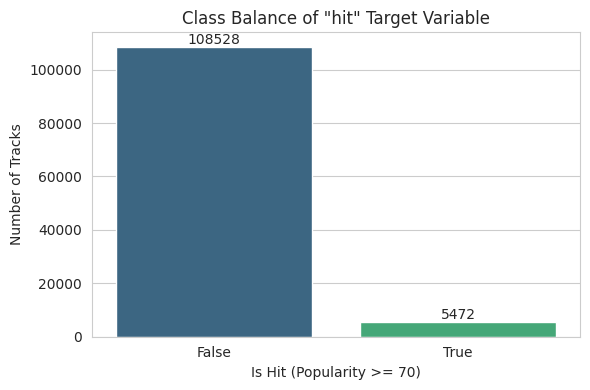

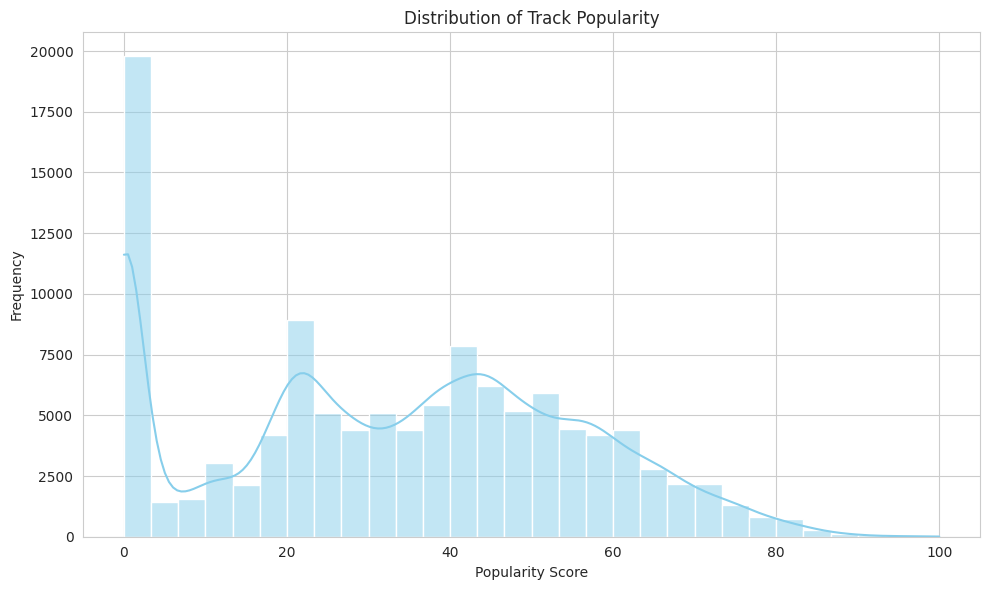

Class balance of 'hit' and distribution of 'popularity' have been plotted and saved.

Numeric features selected for violin plots: ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


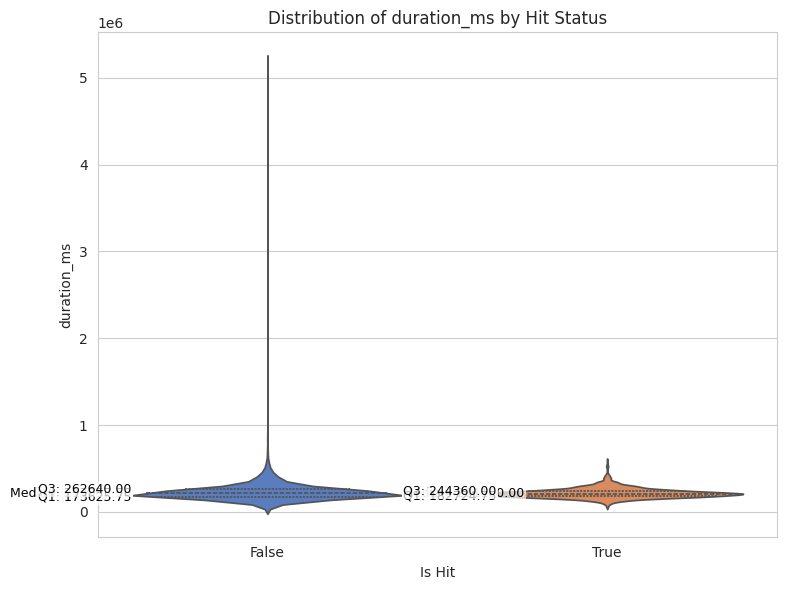

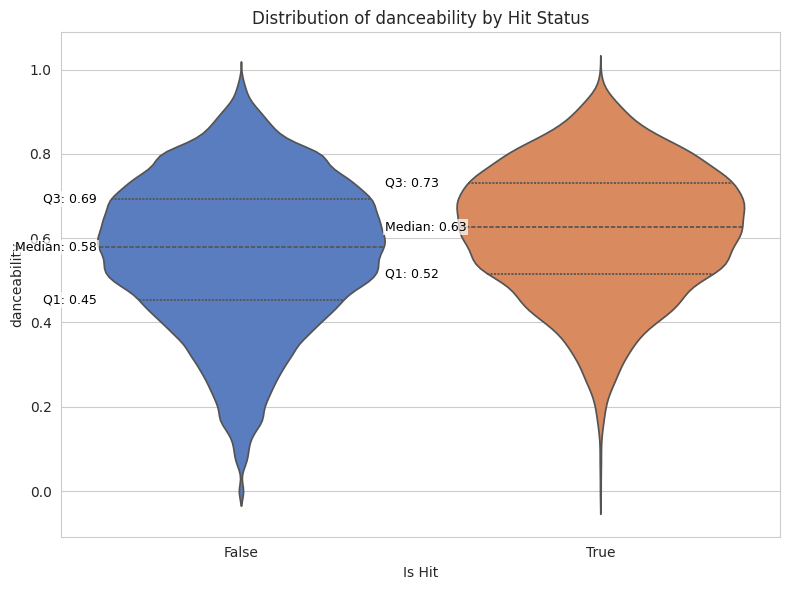

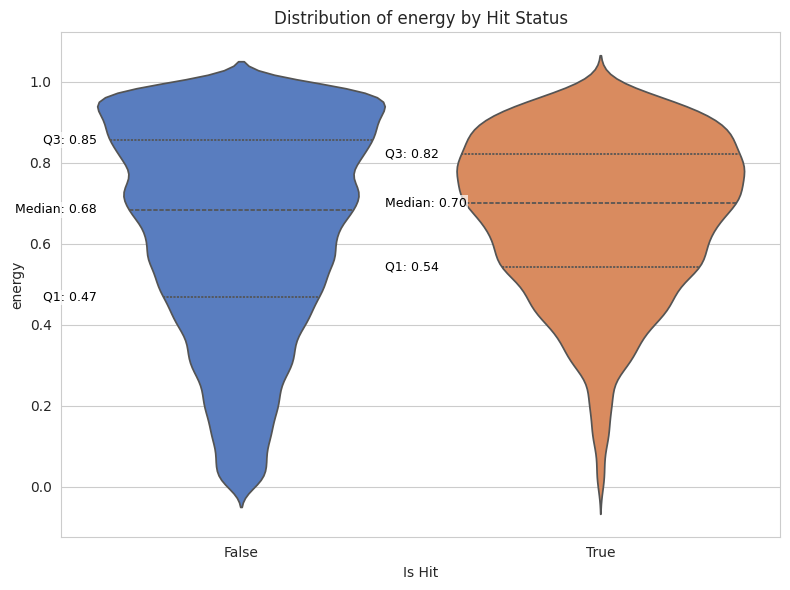

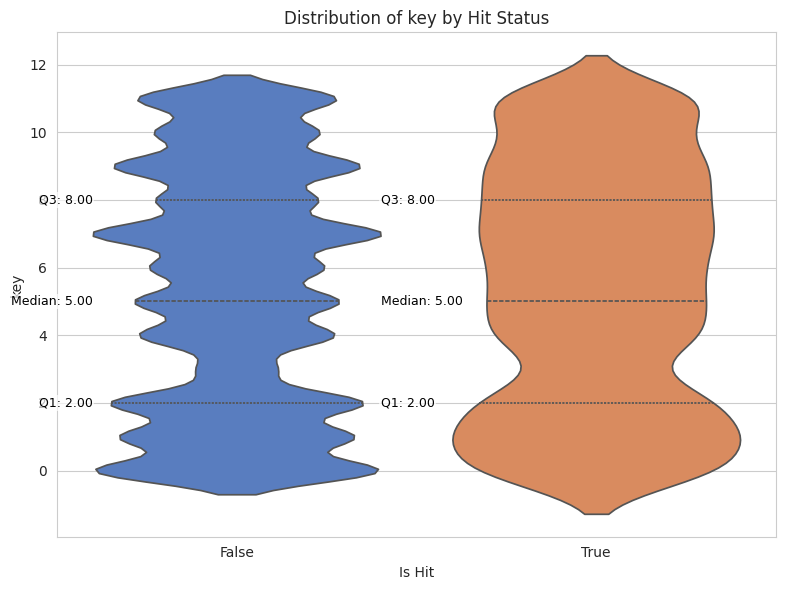

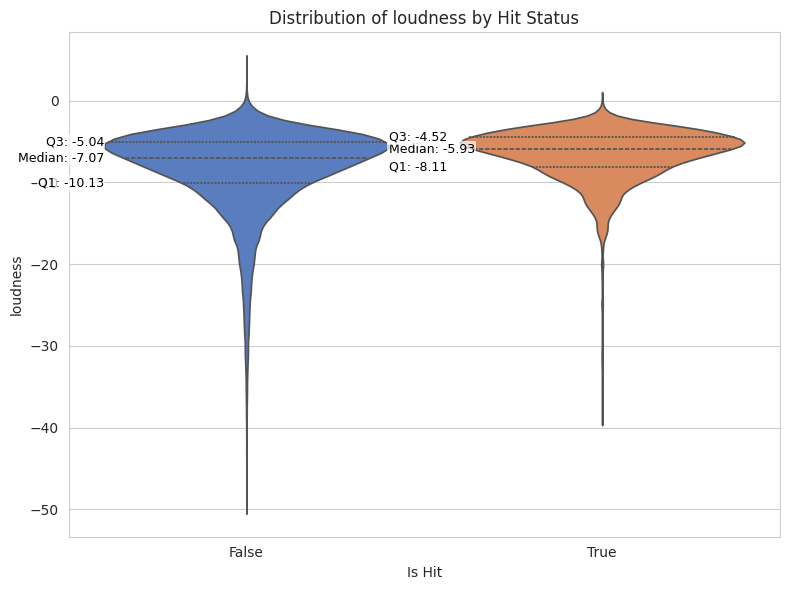

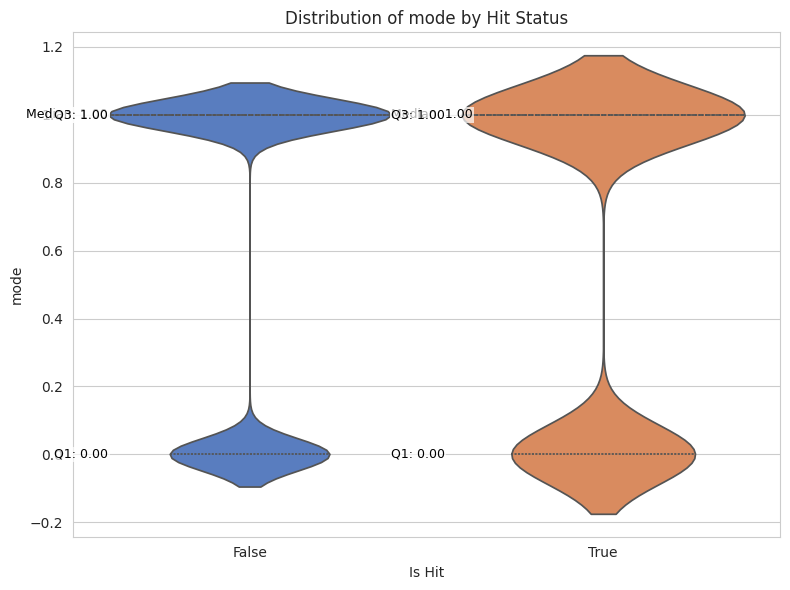

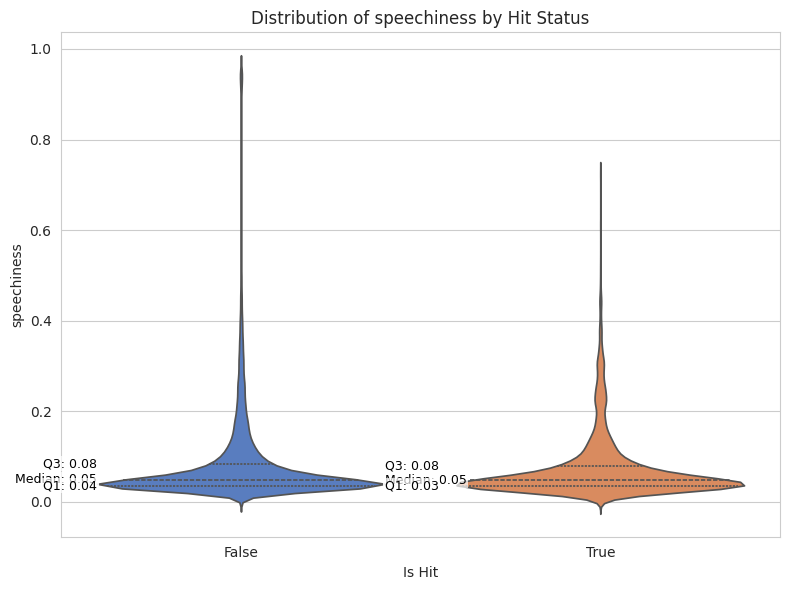

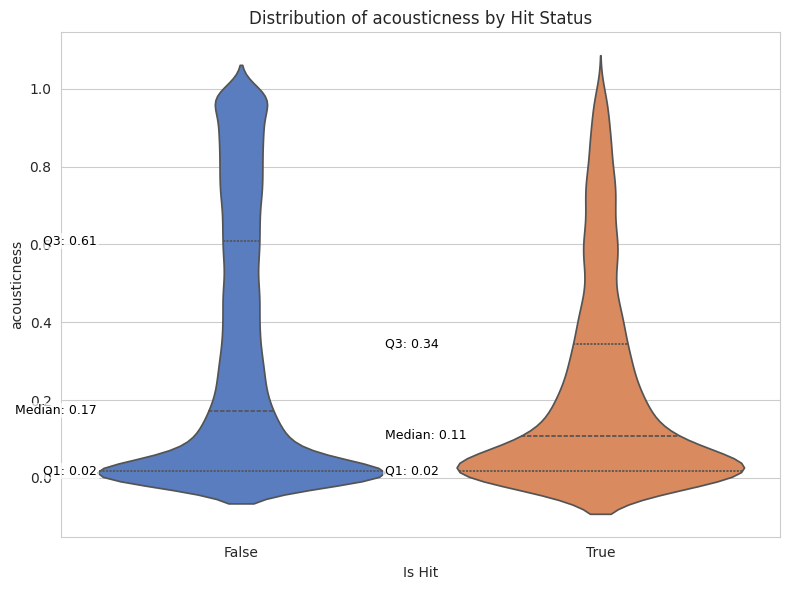

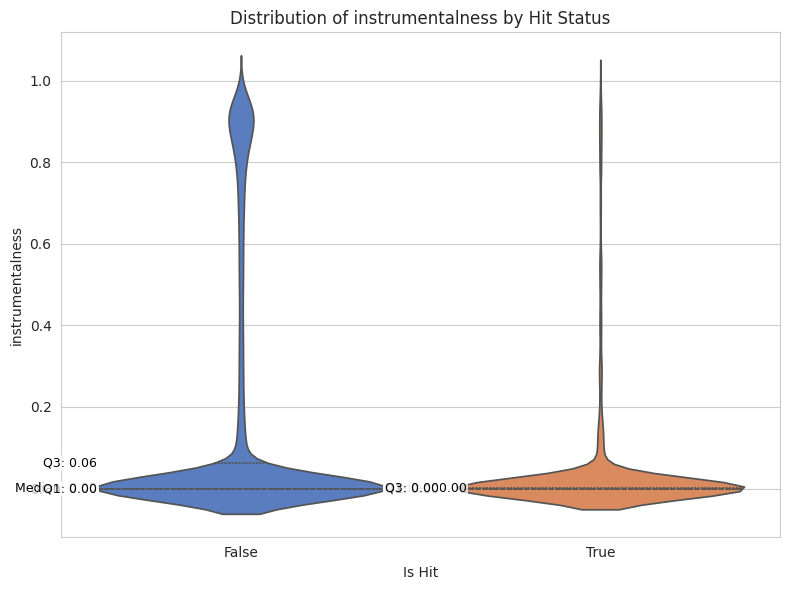

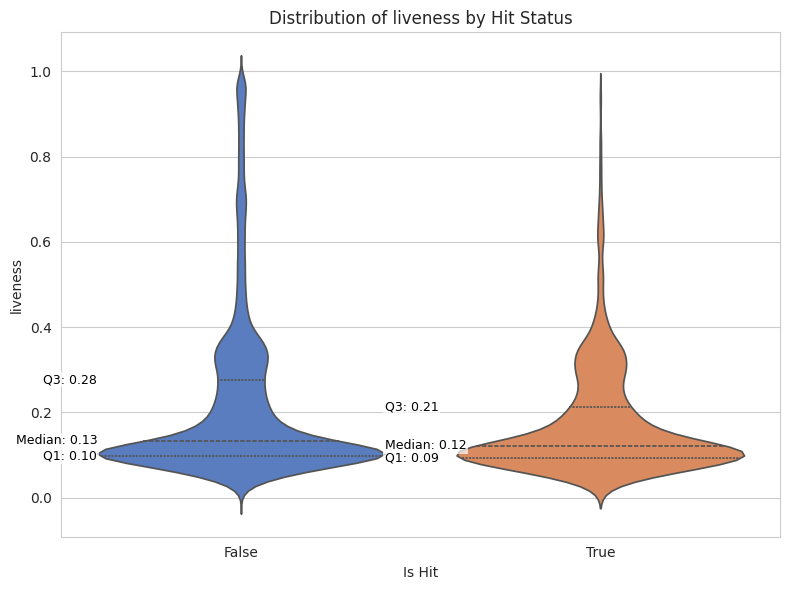

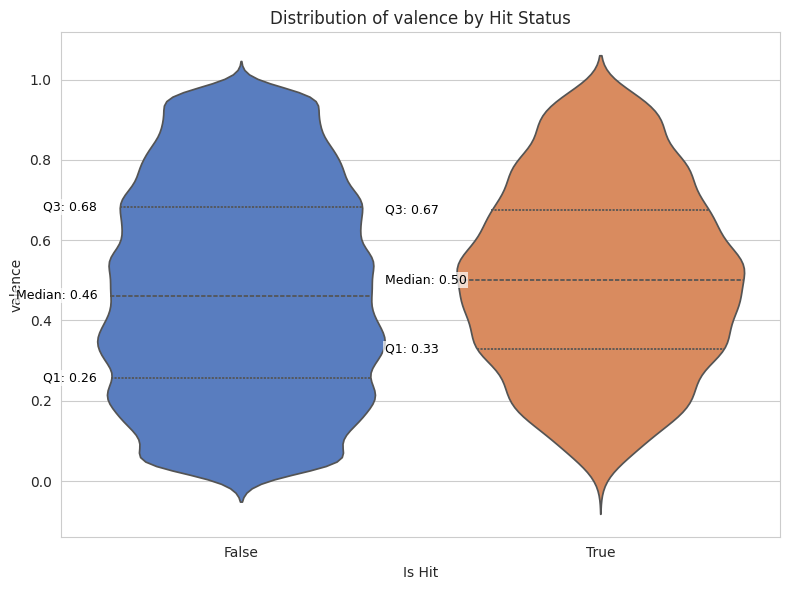

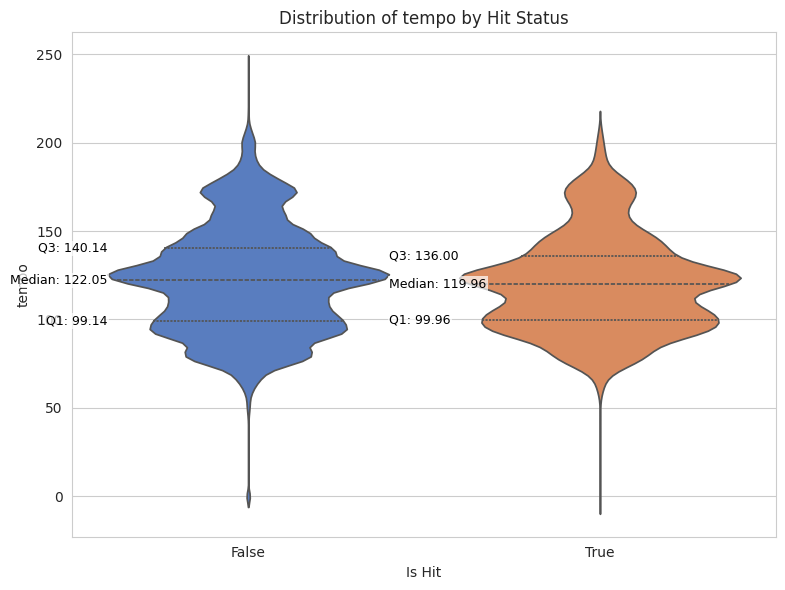

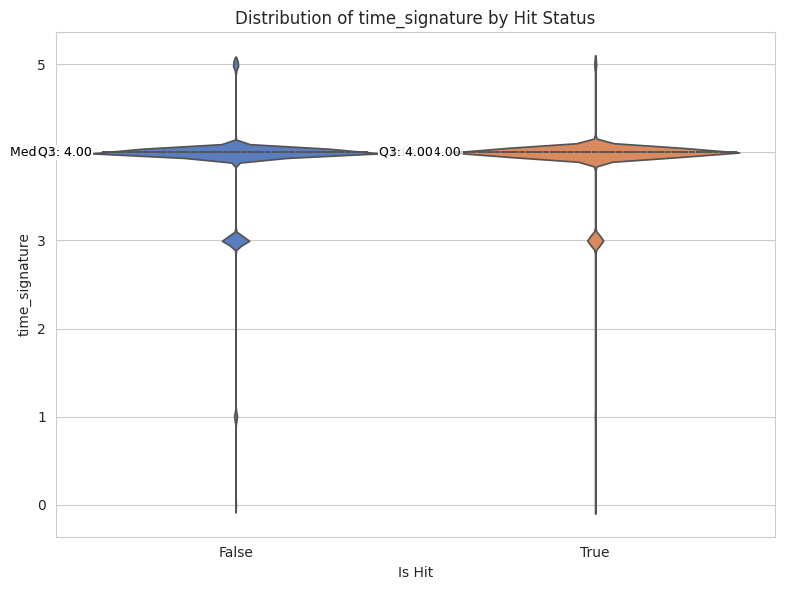

Individual violin plots for numeric features against 'hit' target, with median and quartile annotations, have been generated and saved.

Categorical features selected for plotting: ['explicit', 'track_genre']


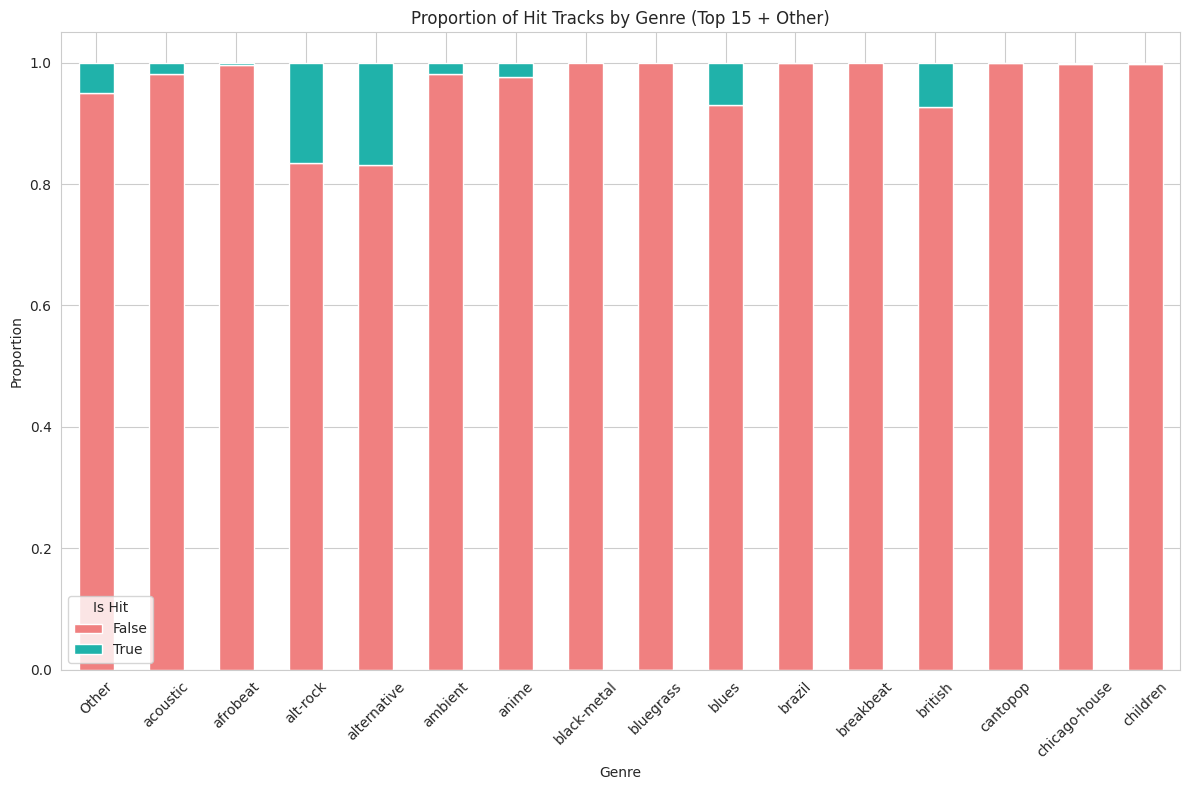

Stacked bar plot for 'track_genre' (grouped) has been generated and saved.


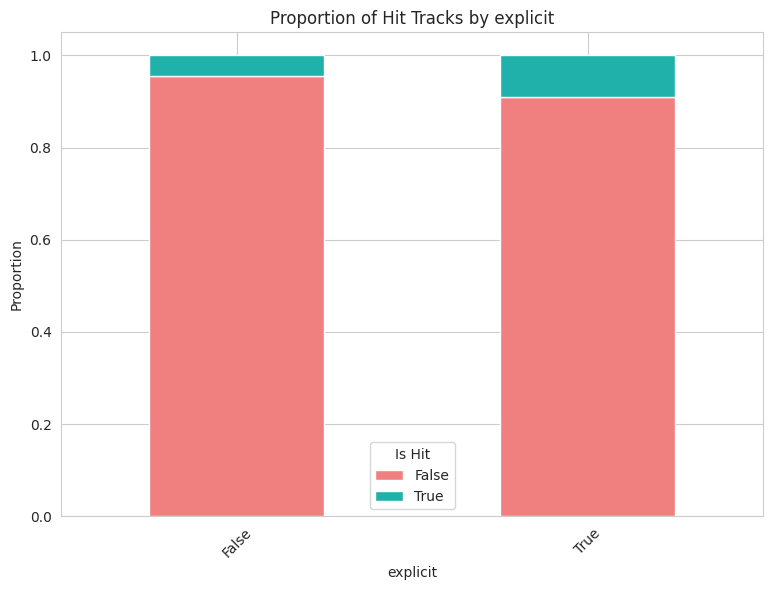

Stacked bar plots for other categorical features have been generated and saved.

# 3. Prepare Data for Feature Selection with Imputation
Numeric columns for imputation: ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Categorical columns for imputation: ['explicit', 'track_genre']

Missing values after imputation:
Series([], dtype: int64)
df_imputed_for_fs prepared for feature selection.

# 4. Feature Association and Ranking
Features (X_fs) shape: (114000, 15)
Target (y_fs) shape: (114000,)
Numeric columns in X_fs: ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Categorical columns in X_fs: ['explicit', 'track_genre']

Mutual Information Scores:
track_genre         0.044169
tempo               0.042230
duration_ms         0.042023
loudness        

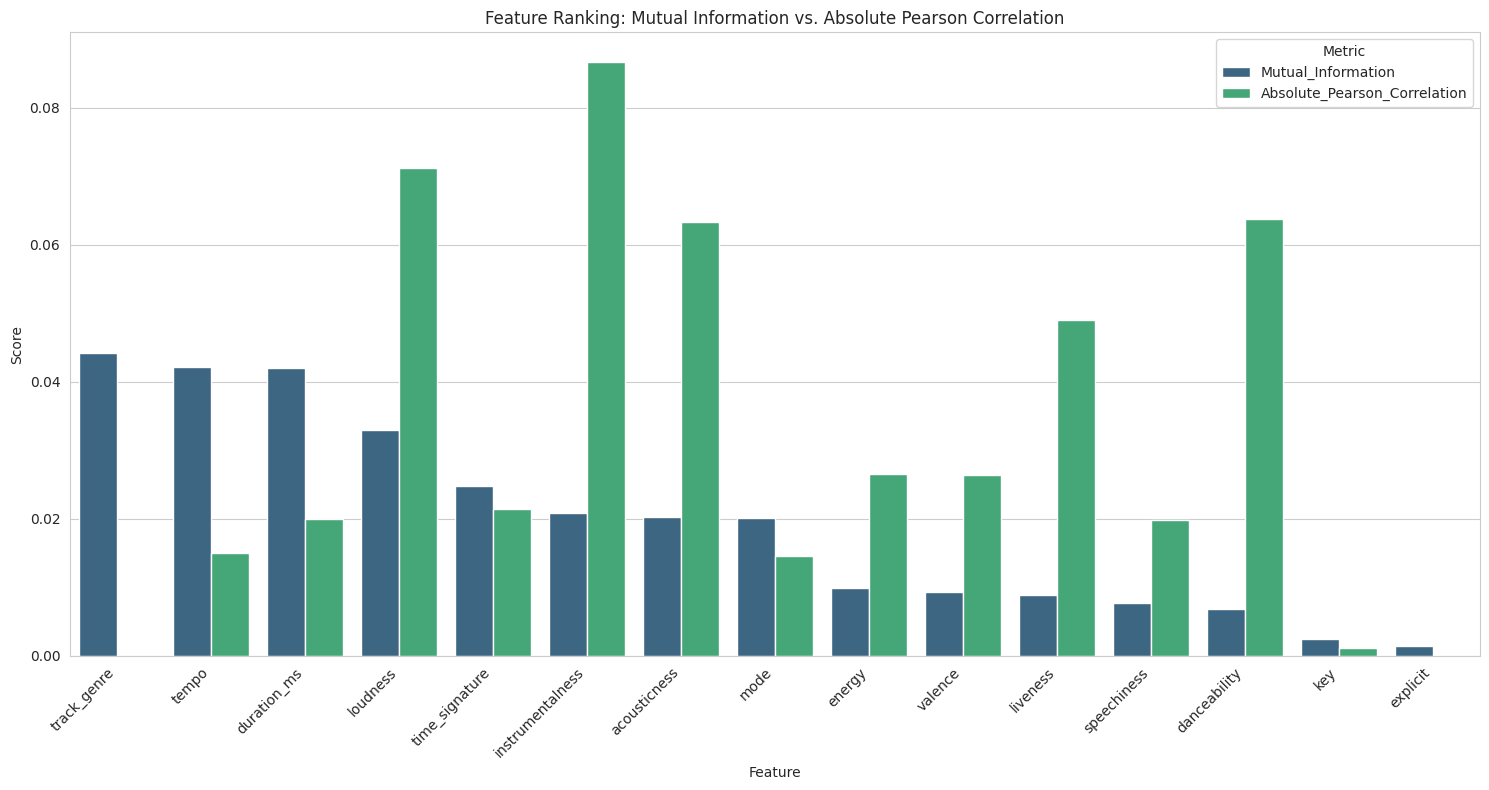

Clustered bar chart of feature rankings has been generated and saved.

Features to be kept for modeling (MI > 0.005 or Corr > 0.01):
['track_genre', 'tempo', 'duration_ms', 'loudness', 'time_signature', 'instrumentalness', 'acousticness', 'mode', 'energy', 'valence', 'liveness', 'speechiness', 'danceability']
Feature selection based on ranking complete.

# 5. Assess Multicollinearity
Numerical features selected for multicollinearity assessment: ['tempo', 'duration_ms', 'loudness', 'time_signature', 'instrumentalness', 'acousticness', 'mode', 'energy', 'valence', 'liveness', 'speechiness', 'danceability']
Correlation matrix calculated.


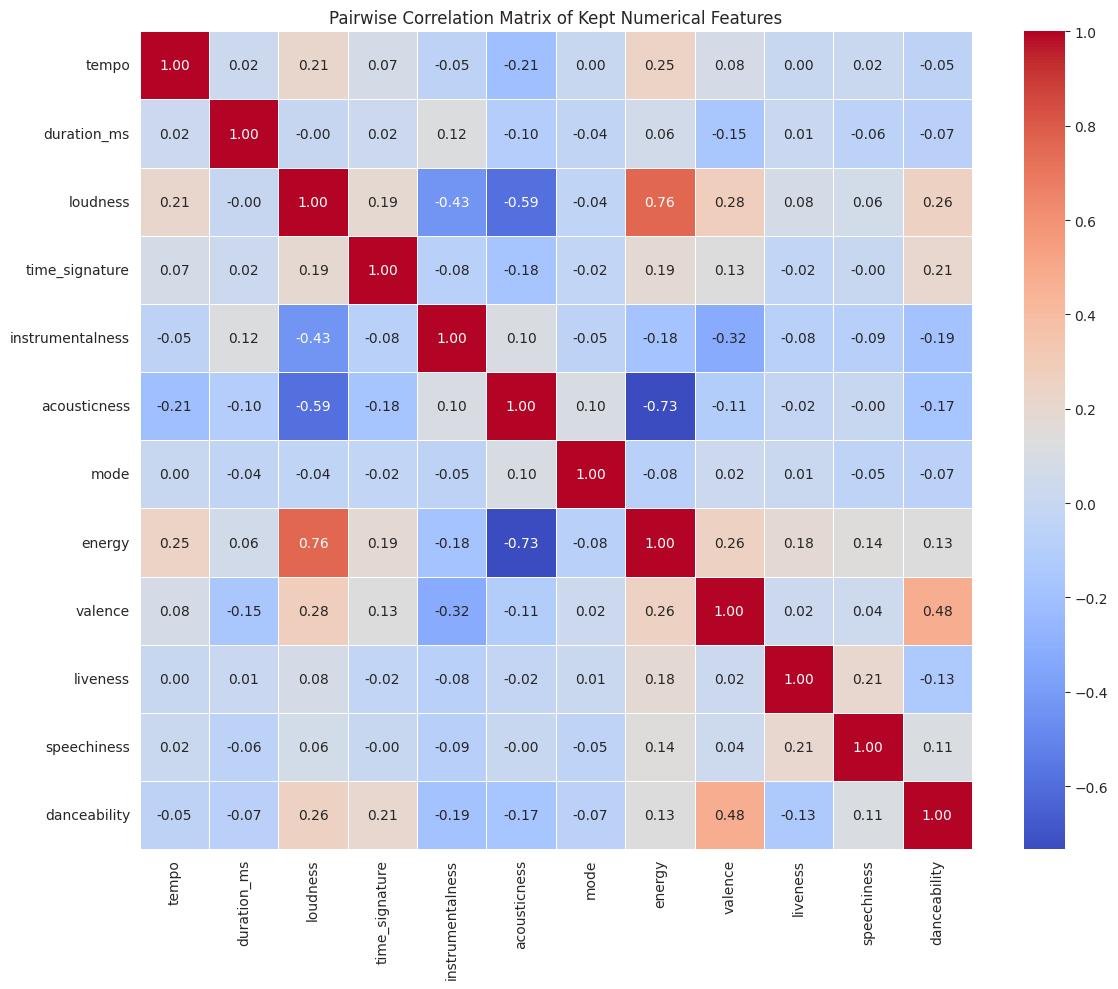

Heatmap of the correlation matrix generated and saved.

No strong multicollinearity (absolute correlation > 0.8) detected among the kept numerical features. This is good for most linear models.

# 6. Data Preprocessing
DataFrame filtered to include only kept features and the target variable.
Data split into training and testing sets.
Numeric features identified for preprocessing: ['tempo', 'duration_ms', 'loudness', 'time_signature', 'instrumentalness', 'acousticness', 'mode', 'energy', 'valence', 'liveness', 'speechiness', 'danceability']
Categorical features identified for preprocessing: ['track_genre']
Preprocessing pipeline (ColumnTransformer) defined.
X_train and X_test have been processed using the ColumnTransformer.
Shape of X_train_processed: (91200, 126)
Shape of X_test_processed: (22800, 126)
Random Under-Sampling applied to training data.
Shape of X_resampled: (8756, 126)
Shape of y_resampled: (8756,)
Class distribution in y_resampled: hit
False    4378
True     4378
Name: c

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:20:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Training and evaluating XGBoost_Weighted...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:20:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


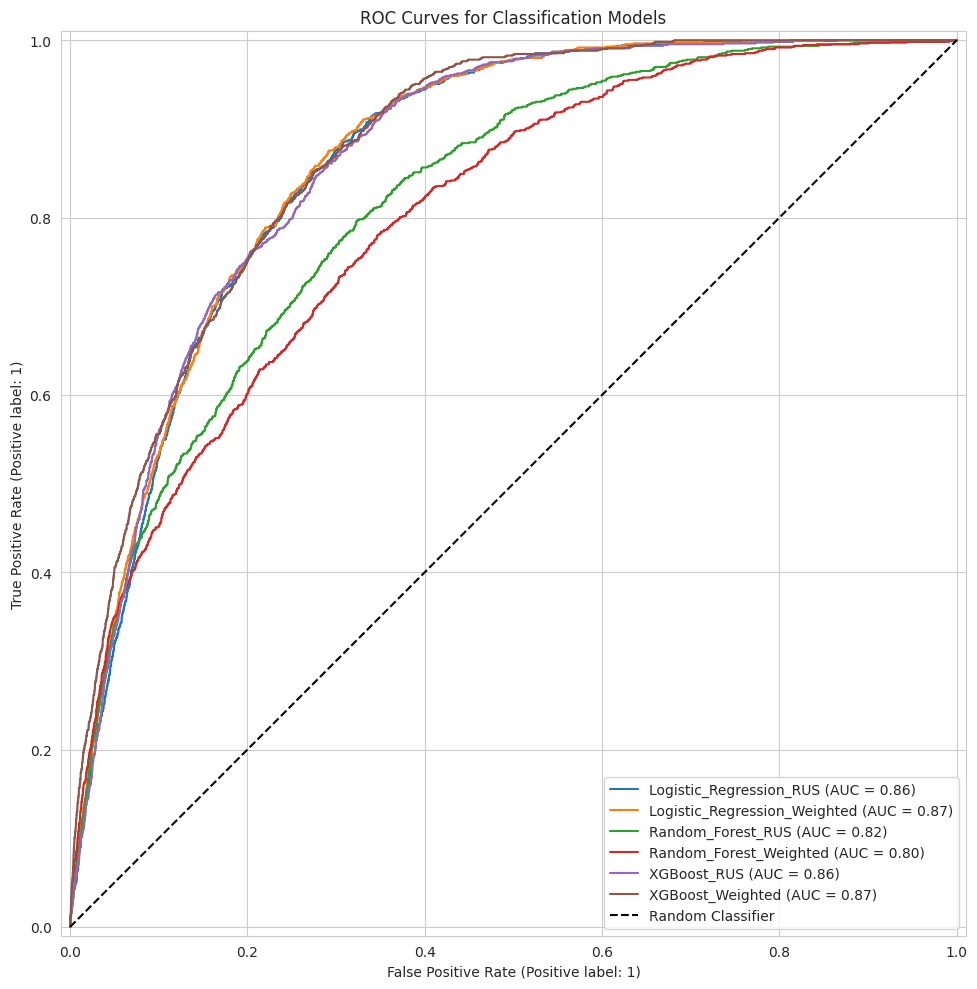

Model training, evaluation, and ROC curve generation complete.

Benchmark Results DataFrame:
                          Model   ROC_AUC  F1_Score  Precision    Recall  \
0       Logistic_Regression_RUS  0.863421  0.234533   0.136150  0.845521   
1  Logistic_Regression_Weighted  0.866477  0.235354   0.136537  0.851920   
2             Random_Forest_RUS  0.815795  0.179388   0.100325  0.846435   
3        Random_Forest_Weighted  0.799136  0.181035   0.102599  0.768739   
4                   XGBoost_RUS  0.864283  0.230945   0.134039  0.833638   
5              XGBoost_Weighted  0.871677  0.244438   0.143827  0.813528   

   Brier_Score  
0     0.167298  
1     0.164629  
2     0.201231  
3     0.187711  
4     0.162893  
5     0.140963  

Benchmark results saved to 'outputs_spotify_m5_project/model_benchmark_results.csv'

# 8. Confusion Matrix for the Best Model


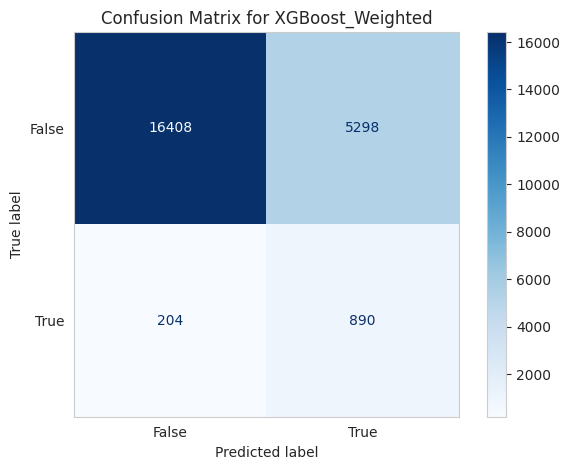

Confusion matrix for XGBoost_Weighted generated and saved.


In [ ]:
# Re-running the consolidated cell
# This cell contains all the steps from initial setup to model benchmarking and evaluation.
# Please execute this cell to re-generate all outputs and figures.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from google.colab import files # Import files for upload

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score, brier_score_loss, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

# Define OUTPUT_DIR and create it if it doesn't exist
OUTPUT_DIR = Path("outputs_spotify_m5_project")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Initial Setup and Data Loading
print("# 1. Initial Setup and Data Loading")

# Upload the dataset file
print("Please upload the 'Spotify Tracks Attributes and Popularity.csv' file.")
uploaded = files.upload()
# Get the uploaded file name
file_name = next(iter(uploaded))

# Load the dataset directly from the file name
df = pd.read_csv(file_name)

# Create the 'hit' target variable
df['hit'] = df['popularity'] >= 70

# Define identifier columns to be excluded from modeling and feature selection
ID_COLUMNS = ['index', 'track_id', 'artists', 'album_name', 'track_name']

print("DataFrame loaded, 'hit' column created, and ID_COLUMNS defined.")
print(f"DataFrame head:\n{df.head()}")
print(f"ID_COLUMNS: {ID_COLUMNS}")

# 2. Exploratory Data Analysis (EDA)
print("\n# 2. Exploratory Data Analysis (EDA)")

sns.set_style("whitegrid")

# 2.1. Base Rates Summary Table for EDA
print("\nBase Rates (Class Distribution of 'hit' target variable):")
hit_counts = df['hit'].value_counts()
total_tracks = df['hit'].count()
hit_percentages = (hit_counts / total_tracks) * 100
base_rates_df = pd.DataFrame({
    'Class': ['Not Hit', 'Hit'],
    'Count': [hit_counts[False], hit_counts[True]],
    'Percentage': [hit_percentages[False], hit_percentages[True]]
})
print(base_rates_df.set_index('Class').to_string(float_format="%.2f%%"))
print("The significant difference in counts and percentages confirms a class imbalance.")

# 2.2. Visualize the class balance of the 'hit' target variable
plt.figure(figsize=(6, 4))
hit_counts = df['hit'].value_counts()
ax = sns.barplot(x=hit_counts.index, y=hit_counts.values, hue=hit_counts.index, palette='viridis', legend=False)
plt.title('Class Balance of "hit" Target Variable')
plt.xlabel('Is Hit (Popularity >= 70)')
plt.ylabel('Number of Tracks')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_class_balance_hit.png", dpi=200)
plt.show()

# 2.3. Visualize the overall distribution of the 'popularity' column
plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_popularity_distribution.png", dpi=200)
plt.show()
print("Class balance of 'hit' and distribution of 'popularity' have been plotted and saved.")

# 2.4. Individual Violin Plots for numeric features
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
features_to_exclude = ID_COLUMNS + ['popularity']
numeric_features_for_plotting = [col for col in numeric_cols if col not in features_to_exclude]

print(f"\nNumeric features selected for violin plots: {numeric_features_for_plotting}")

for col in numeric_features_for_plotting:
    plt.figure(figsize=(8, 6))
    sns.violinplot(x='hit', y=col, data=df, hue='hit', palette='muted', legend=False, inner='quartile')
    hit_false_data = df[df['hit'] == False][col].dropna()
    hit_true_data = df[df['hit'] == True][col].dropna()

    if not hit_false_data.empty:
        q1_false, median_false, q3_false = np.percentile(hit_false_data, [25, 50, 75])
        plt.text(-0.4, median_false, f'Median: {median_false:.2f}', color='black', ha='right', va='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        plt.text(-0.4, q1_false, f'Q1: {q1_false:.2f}', color='black', ha='right', va='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        plt.text(-0.4, q3_false, f'Q3: {q3_false:.2f}', color='black', ha='right', va='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    if not hit_true_data.empty:
        q1_true, median_true, q3_true = np.percentile(hit_true_data, [25, 50, 75])
        plt.text(0.4, median_true, f'Median: {median_true:.2f}', color='black', ha='left', va='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        plt.text(0.4, q1_true, f'Q1: {q1_true:.2f}', color='black', ha='left', va='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        plt.text(0.4, q3_true, f'Q3: {q3_true:.2f}', color='black', ha='left', va='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    plt.title(f'Distribution of {col} by Hit Status')
    plt.xlabel('Is Hit')
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"eda_violin_plot_{col}.png", dpi=200)
    plt.show()
print("Individual violin plots for numeric features against 'hit' target, with median and quartile annotations, have been generated and saved.")

# 2.5. Stacked bar plots for categorical features
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
features_to_exclude_cat = ID_COLUMNS + ['hit']
categorical_features_for_plotting = [col for col in categorical_cols if col not in features_to_exclude_cat]

print(f"\nCategorical features selected for plotting: {categorical_features_for_plotting}")

if 'track_genre' in categorical_features_for_plotting:
    genre_counts = df['track_genre'].value_counts()
    N_top_genres = 15
    top_genres = genre_counts.head(N_top_genres).index.tolist()
    df['track_genre_grouped'] = df['track_genre'].apply(lambda x: x if x in top_genres else 'Other')

    genre_crosstab = pd.crosstab(df['track_genre_grouped'], df['hit'], normalize='index')

    plt.figure(figsize=(12, 8))
    genre_crosstab.plot(kind='bar', stacked=True, color=['lightcoral', 'lightseagreen'], ax=plt.gca())
    plt.title(f'Proportion of Hit Tracks by Genre (Top {N_top_genres} + Other)')
    plt.xlabel('Genre')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(title='Is Hit')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "eda_stacked_bar_track_genre_grouped.png", dpi=200)
    plt.show()
    categorical_features_for_plotting.remove('track_genre')
print("Stacked bar plot for 'track_genre' (grouped) has been generated and saved.")

if categorical_features_for_plotting:
    num_plots = len(categorical_features_for_plotting)
    fig, axes = plt.subplots(nrows=(num_plots + 1) // 2, ncols=2, figsize=(15, 6 * ((num_plots + 1) // 2)))
    axes = axes.flatten()
    for i, col in enumerate(categorical_features_for_plotting):
        plot_df = df.copy()
        if col == 'explicit':
            plot_df[col] = plot_df[col].astype(str)
        crosstab = pd.crosstab(plot_df[col], plot_df['hit'], normalize='index')
        crosstab.plot(kind='bar', stacked=True, color=['lightcoral', 'lightseagreen'], ax=axes[i])
        axes[i].set_title(f'Proportion of Hit Tracks by {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Proportion')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(title='Is Hit')
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "eda_stacked_bar_other_categorical.png", dpi=200)
    plt.show()
    print("Stacked bar plots for other categorical features have been generated and saved.")
else:
    print("No other categorical features to plot.")

# 3. Prepare Data for Feature Selection with Imputation
print("\n# 3. Prepare Data for Feature Selection with Imputation")

df_imputed_for_fs = df.copy()
df_imputed_for_fs = df_imputed_for_fs.drop(columns=ID_COLUMNS)

numeric_cols_for_imputation = df_imputed_for_fs.select_dtypes(include=['number']).columns.tolist()
if 'popularity' in numeric_cols_for_imputation:
    numeric_cols_for_imputation.remove('popularity')

categorical_cols_for_imputation = df_imputed_for_fs.select_dtypes(include=['object', 'bool']).columns.tolist()
if 'hit' in categorical_cols_for_imputation:
    categorical_cols_for_imputation.remove('hit')
if 'track_genre_grouped' in categorical_cols_for_imputation:
    categorical_cols_for_imputation.remove('track_genre_grouped')

print(f"Numeric columns for imputation: {numeric_cols_for_imputation}")
print(f"Categorical columns for imputation: {categorical_cols_for_imputation}")

for col in numeric_cols_for_imputation:
    if df_imputed_for_fs[col].isnull().any():
        median_val = df_imputed_for_fs[col].median()
        df_imputed_for_fs[col].fillna(median_val, inplace=True)
        print(f"Imputed missing values in numeric column '{col}' with median: {median_val}")

for col in categorical_cols_for_imputation:
    if df_imputed_for_fs[col].isnull().any():
        mode_val = df_imputed_for_fs[col].mode()[0]
        df_imputed_for_fs[col].fillna(mode_val, inplace=True)
        print(f"Imputed missing values in categorical column '{col}' with mode: {mode_val}")

missing_values_after_imputation = df_imputed_for_fs.isnull().sum()
print("\nMissing values after imputation:")
print(missing_values_after_imputation[missing_values_after_imputation > 0])
print("df_imputed_for_fs prepared for feature selection.")

# 4. Feature Association and Ranking
print("\n# 4. Feature Association and Ranking")

X_fs = df_imputed_for_fs.drop(columns=['hit', 'popularity', 'track_genre_grouped']) # 'popularity' and 'track_genre_grouped' might not exist, but dropping them is safe.
y_fs = df_imputed_for_fs['hit']

numeric_cols_X_fs = X_fs.select_dtypes(include=['number']).columns.tolist()
categorical_cols_X_fs = X_fs.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Features (X_fs) shape: {X_fs.shape}")
print(f"Target (y_fs) shape: {y_fs.shape}")
print(f"Numeric columns in X_fs: {numeric_cols_X_fs}")
print(f"Categorical columns in X_fs: {categorical_cols_X_fs}")

X_fs_encoded = X_fs.copy()
is_discrete = []

for col in X_fs.columns:
    if col in categorical_cols_X_fs:
        X_fs_encoded[col] = pd.factorize(X_fs_encoded[col])[0]
        is_discrete.append(True)
    elif col in numeric_cols_X_fs:
        is_discrete.append(False)

mi_scores = mutual_info_classif(X_fs_encoded, y_fs, discrete_features=is_discrete, random_state=42)
mi_series = pd.Series(mi_scores, index=X_fs.columns).sort_values(ascending=False)

print("\nMutual Information Scores:")
print(mi_series)

y_fs_numeric = y_fs.astype(int)
absolute_correlations = df_imputed_for_fs[numeric_cols_X_fs].corrwith(y_fs_numeric).abs().sort_values(ascending=False)

print("\nAbsolute Pearson Correlation Scores (Numeric Features Only):")
print(absolute_correlations)

feature_ranking_df = pd.DataFrame({'Mutual_Information': mi_series, 'Absolute_Pearson_Correlation': absolute_correlations})
feature_ranking_df = feature_ranking_df.fillna(0)
feature_ranking_df = feature_ranking_df.sort_values(by=['Mutual_Information', 'Absolute_Pearson_Correlation'], ascending=False)

print("\nCombined Feature Ranking:")
print(feature_ranking_df)
feature_ranking_df.to_csv(OUTPUT_DIR / 'feature_ranking.csv')
print(f"\nFeature ranking saved to '{OUTPUT_DIR / 'feature_ranking.csv'}'")

feature_ranking_melted = feature_ranking_df.reset_index().rename(columns={'index': 'Feature'})
feature_ranking_melted = feature_ranking_melted.melt(id_vars='Feature', var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 8))
sns.barplot(x='Feature', y='Score', hue='Metric', data=feature_ranking_melted, palette='viridis')
plt.title('Feature Ranking: Mutual Information vs. Absolute Pearson Correlation')
plt.xlabel('Feature')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_ranking_clustered_bar_chart.png", dpi=200)
plt.show()
print("Clustered bar chart of feature rankings has been generated and saved.")

mi_threshold = 0.005
corr_threshold = 0.01

kept_features = feature_ranking_df[
    (feature_ranking_df['Mutual_Information'] > mi_threshold) |
    (feature_ranking_df['Absolute_Pearson_Correlation'] > corr_threshold)
].index.tolist()

print(f"\nFeatures to be kept for modeling (MI > {mi_threshold} or Corr > {corr_threshold}):")
print(kept_features)
print("Feature selection based on ranking complete.")

# 5. Assess Multicollinearity
print("\n# 5. Assess Multicollinearity")

kept_features_df = df_imputed_for_fs[kept_features + ['hit']].copy()
numerical_kept_features = kept_features_df.select_dtypes(include=np.number).columns.tolist()

if 'hit' in numerical_kept_features:
    numerical_kept_features.remove('hit')

print(f"Numerical features selected for multicollinearity assessment: {numerical_kept_features}")

correlation_matrix = kept_features_df[numerical_kept_features].corr()
print("Correlation matrix calculated.")

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pairwise Correlation Matrix of Kept Numerical Features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "multicollinearity_heatmap.png", dpi=200)
plt.show()
print("Heatmap of the correlation matrix generated and saved.")

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            high_corr_pairs.append(f"{col1} - {col2}: {correlation_matrix.iloc[i, j]:.2f}")

if high_corr_pairs:
    print("\nHigh multicollinearity detected! Pairs with absolute correlation > 0.8:")
    for pair in high_corr_pairs:
        print(pair)
    print("\nRecommendations to address multicollinearity:")
    print("1. Remove one of the highly correlated features (e.g., keep 'energy' and remove 'loudness' if they are highly correlated). This can be decided based on feature importance or domain knowledge.")
    print("2. Use dimensionality reduction techniques like Principal Component Analysis (PCA) to create new, uncorrelated features.")
    print("3. Use models that are robust to multicollinearity, such as tree-based models (Random Forest, Gradient Boosting) or regularized regression models (Ridge, Lasso).")
else:
    print("\nNo strong multicollinearity (absolute correlation > 0.8) detected among the kept numerical features. This is good for most linear models.")

# 6. Data Preprocessing
print("\n# 6. Data Preprocessing")

df_filtered = df[kept_features + ['hit']].copy()
print("DataFrame filtered to include only kept features and the target variable.")

X = df_filtered.drop(columns=['hit'])
y = df_filtered['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data split into training and testing sets.")

numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Numeric features identified for preprocessing: {numeric_features}")
print(f"Categorical features identified for preprocessing: {categorical_features}")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)
print("Preprocessing pipeline (ColumnTransformer) defined.")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("X_train and X_test have been processed using the ColumnTransformer.")
print(f"Shape of X_train_processed: {X_train_processed.shape}")
print(f"Shape of X_test_processed: {X_test_processed.shape}")

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

print("Random Under-Sampling applied to training data.")
print(f"Shape of X_resampled: {X_resampled.shape}")
print(f"Shape of y_resampled: {y_resampled.shape}")
print(f"Class distribution in y_resampled: {y_resampled.value_counts()}")

# 7. Six-Model Benchmark
print("\n# 7. Six-Model Benchmark")

neg_count = y_train.value_counts()[False]
pos_count = y_train.value_counts()[True]
scale_pos_weight_value = neg_count / pos_count

print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight_value:.2f}")

models = {
    'Logistic_Regression_RUS': LogisticRegression(random_state=42, solver='liblinear', penalty='l1'),
    'Logistic_Regression_Weighted': LogisticRegression(random_state=42, solver='liblinear', penalty='l1', class_weight='balanced'),
    'Random_Forest_RUS': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    'Random_Forest_Weighted': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, class_weight='balanced'),
    'XGBoost_RUS': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_estimators=100, max_depth=5),
    'XGBoost_Weighted': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_estimators=100, max_depth=5, scale_pos_weight=scale_pos_weight_value)
}
print("Model dictionary defined.")

benchmark_results = []
plt.figure(figsize=(12, 10))

for name, model in models.items():
    print(f"\nTraining and evaluating {name}...")
    if 'RUS' in name:
        model.fit(X_resampled, y_resampled)
    else:
        model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_proba)

    benchmark_results.append({
        'Model': name,
        'ROC_AUC': roc_auc,
        'F1_Score': f1,
        'Precision': precision,
        'Recall': recall,
        'Brier_Score': brier
    })

    RocCurveDisplay.from_estimator(model, X_test_processed, y_test, name=name, ax=plt.gca())

plt.title('ROC Curves for Classification Models')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves_all_models.png", dpi=200)
plt.show()
print("Model training, evaluation, and ROC curve generation complete.")

benchmark_results_df = pd.DataFrame(benchmark_results)
print("\nBenchmark Results DataFrame:")
print(benchmark_results_df)
benchmark_results_df.to_csv(OUTPUT_DIR / 'model_benchmark_results.csv', index=False)
print(f"\nBenchmark results saved to '{OUTPUT_DIR / 'model_benchmark_results.csv'}'")

# 8. Confusion Matrix for the Best Model
print("\n# 8. Confusion Matrix for the Best Model")

best_model_name = benchmark_results_df.loc[benchmark_results_df['ROC_AUC'].idxmax(), 'Model']
best_model = models[best_model_name]

y_pred_best_model = best_model.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_best_model, labels=[False, True])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[False, True])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.tight_layout()
disp.ax_.grid(False)
plt.savefig(OUTPUT_DIR / "confusion_matrix_best_model.png", dpi=200)
plt.show()

print(f"Confusion matrix for {best_model_name} generated and saved.")